# Background Noise Augmentation Test
Tests `mix_mild_background` from `Dataset_safe_train_BG` in `data_utils.py`.
Set `AUDIO_PATH` below before running.

In [8]:
import sys
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import glob
import os
from IPython.display import Audio, display

sys.path.insert(0, '/home/jsudan/wav2vec_contr_loss')
from RawBoost import LnL_convolutive_noise, SSI_additive_noise, ISD_additive_noise, normWav

# --- SET YOUR AUDIO PATH HERE ---
AUDIO_PATH = "/data/Data/ASVSpoofData_2019/train/LA/ASVspoof2019_LA_train/flac/LA_T_1001074.flac"
BG_DIR     = "/data/FF_V2/Speaker_Specific_OCSVM/Mixture/additional noise"
SR         = 16000
BG_SNR_MIN = 18.0
BG_SNR_MAX = 28.0

In [9]:
# Copied verbatim from Dataset_safe_train_BG.mix_mild_background
def mix_mild_background(speech, sr, bg_dir, snr_range=(18, 28)):
    bg_files = glob.glob(os.path.join(bg_dir, "*.mp3"))
    if len(bg_files) == 0:
        return speech

    bg_path = random.choice(bg_files)
    print(f"  noise file: {os.path.basename(bg_path)}")
    bg, _ = librosa.load(bg_path, sr=sr, mono=True)

    if len(bg) == 0:
        return speech

    if len(bg) < len(speech):
        repeat_count = int(np.ceil(len(speech) / len(bg)))
        bg = np.tile(bg, repeat_count)

    start = random.randint(0, len(bg) - len(speech))
    bg = bg[start:start + len(speech)]
    bg = bg - np.mean(bg)

    speech_power = np.mean(speech ** 2) + 1e-8
    bg_power     = np.mean(bg ** 2) + 1e-8
    snr_db       = random.uniform(snr_range[0], snr_range[1])
    print(f"  SNR: {snr_db:.1f} dB")

    target_bg_power = speech_power / (10 ** (snr_db / 10))
    bg = bg * np.sqrt(target_bg_power / bg_power)

    mixed = speech + bg
    max_val = np.max(np.abs(mixed)) + 1e-8
    if max_val > 1.0:
        mixed = mixed / max_val

    return mixed.astype(np.float32)


def apply_rawboost(x, fs=16000):
    y = LnL_convolutive_noise(
        x, N_f=5, nBands=5,
        minF=20.0, maxF=8000.0,
        minBW=100.0, maxBW=1000.0,
        minCoeff=10, maxCoeff=100,
        minG=0.0, maxG=0.0,
        minBiasLinNonLin=5.0, maxBiasLinNonLin=20.0,
        fs=fs,
    )
    if random.random() < 0.5:
        y = SSI_additive_noise(
            y, SNRmin=10.0, SNRmax=40.0, nBands=5,
            minF=20.0, maxF=8000.0, minBW=100.0, maxBW=1000.0,
            minCoeff=10, maxCoeff=100, minG=0.0, maxG=0.0,
            fs=fs,
        )
    if random.random() < 0.5:
        y = ISD_additive_noise(y, P=10.0, g_sd=2.0)
    # trim/pad to original length
    if len(y) > len(x):
        y = y[:len(x)]
    elif len(y) < len(x):
        y = np.pad(y, (0, len(x) - len(y)))
    return y.astype(np.float32)

In [10]:
# Load original
original, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
print(f"Loaded: {os.path.basename(AUDIO_PATH)}  |  {len(original)/SR:.2f}s  |  {len(original)} samples")

print("\nApplying BG noise...")
aug_bg = mix_mild_background(original.copy(), SR, BG_DIR, (BG_SNR_MIN, BG_SNR_MAX))

print("\nApplying RawBoost...")
aug_rb = apply_rawboost(original.copy(), SR)

print("\nApplying BG noise + RawBoost...")
aug_both = apply_rawboost(mix_mild_background(original.copy(), SR, BG_DIR, (BG_SNR_MIN, BG_SNR_MAX)), SR)

Loaded: LA_T_1001074.flac  |  3.76s  |  60233 samples

Applying BG noise...
  noise file: ncprime-noncopyright-music-pianos-295174.mp3
  SNR: 21.4 dB

Applying RawBoost...

Applying BG noise + RawBoost...
  noise file: sergequadrado-cool-hip-hop-loop-275527.mp3
  SNR: 20.2 dB


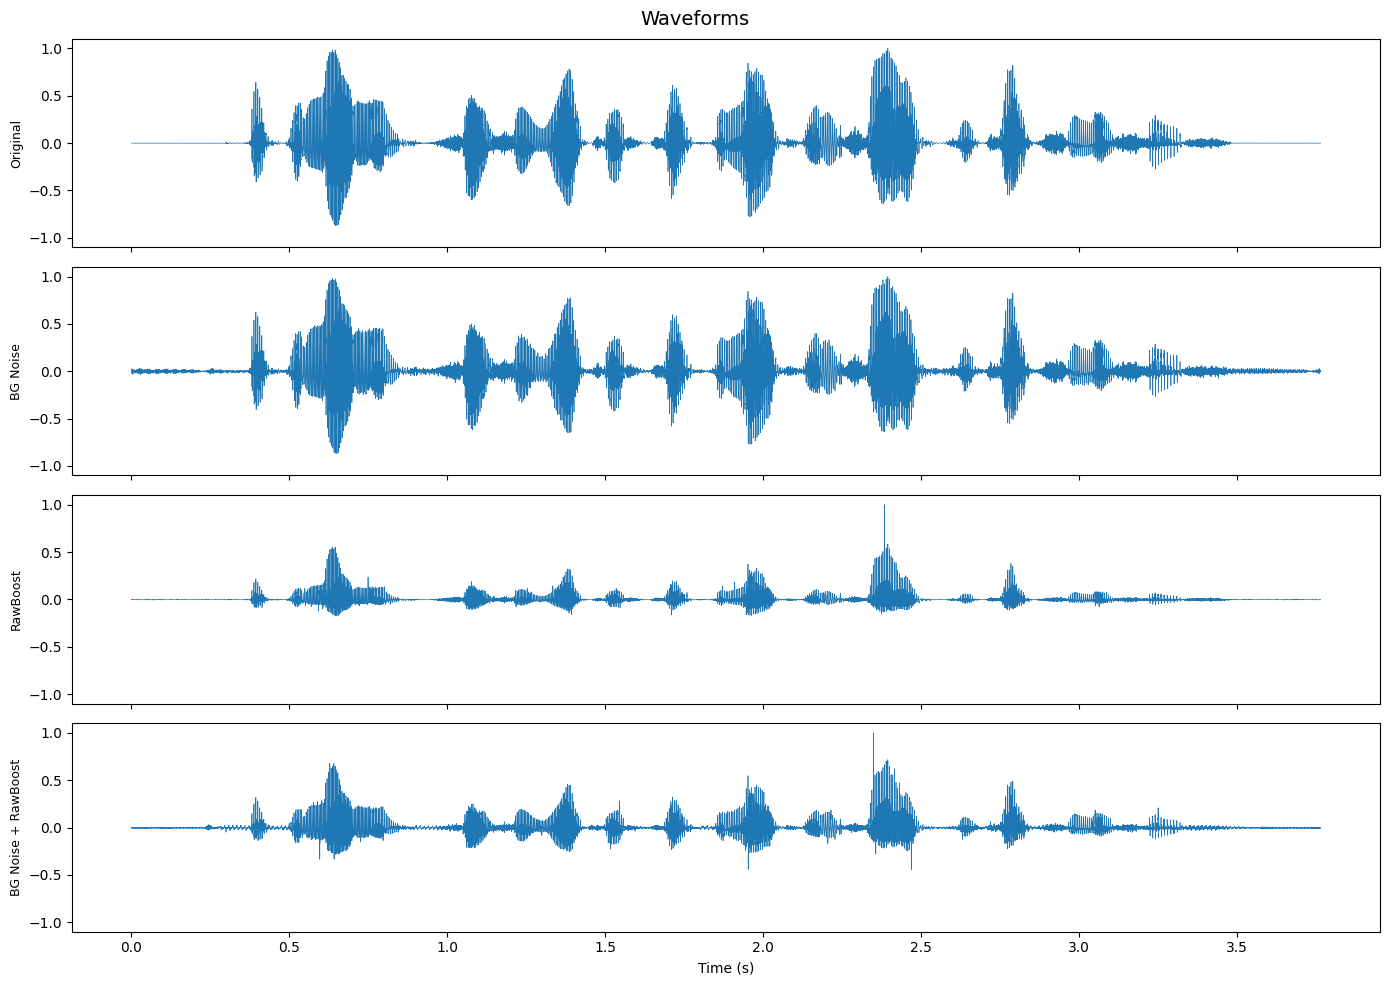

In [11]:
variants = [
    ("Original",              original),
    ("BG Noise",              aug_bg),
    ("RawBoost",              aug_rb),
    ("BG Noise + RawBoost",   aug_both),
]
t = np.linspace(0, len(original) / SR, len(original))

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Waveforms", fontsize=14)
for ax, (title, wav) in zip(axes, variants):
    ax.plot(t, wav, linewidth=0.5)
    ax.set_ylabel(title, fontsize=9)
    ax.set_ylim(-1.1, 1.1)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

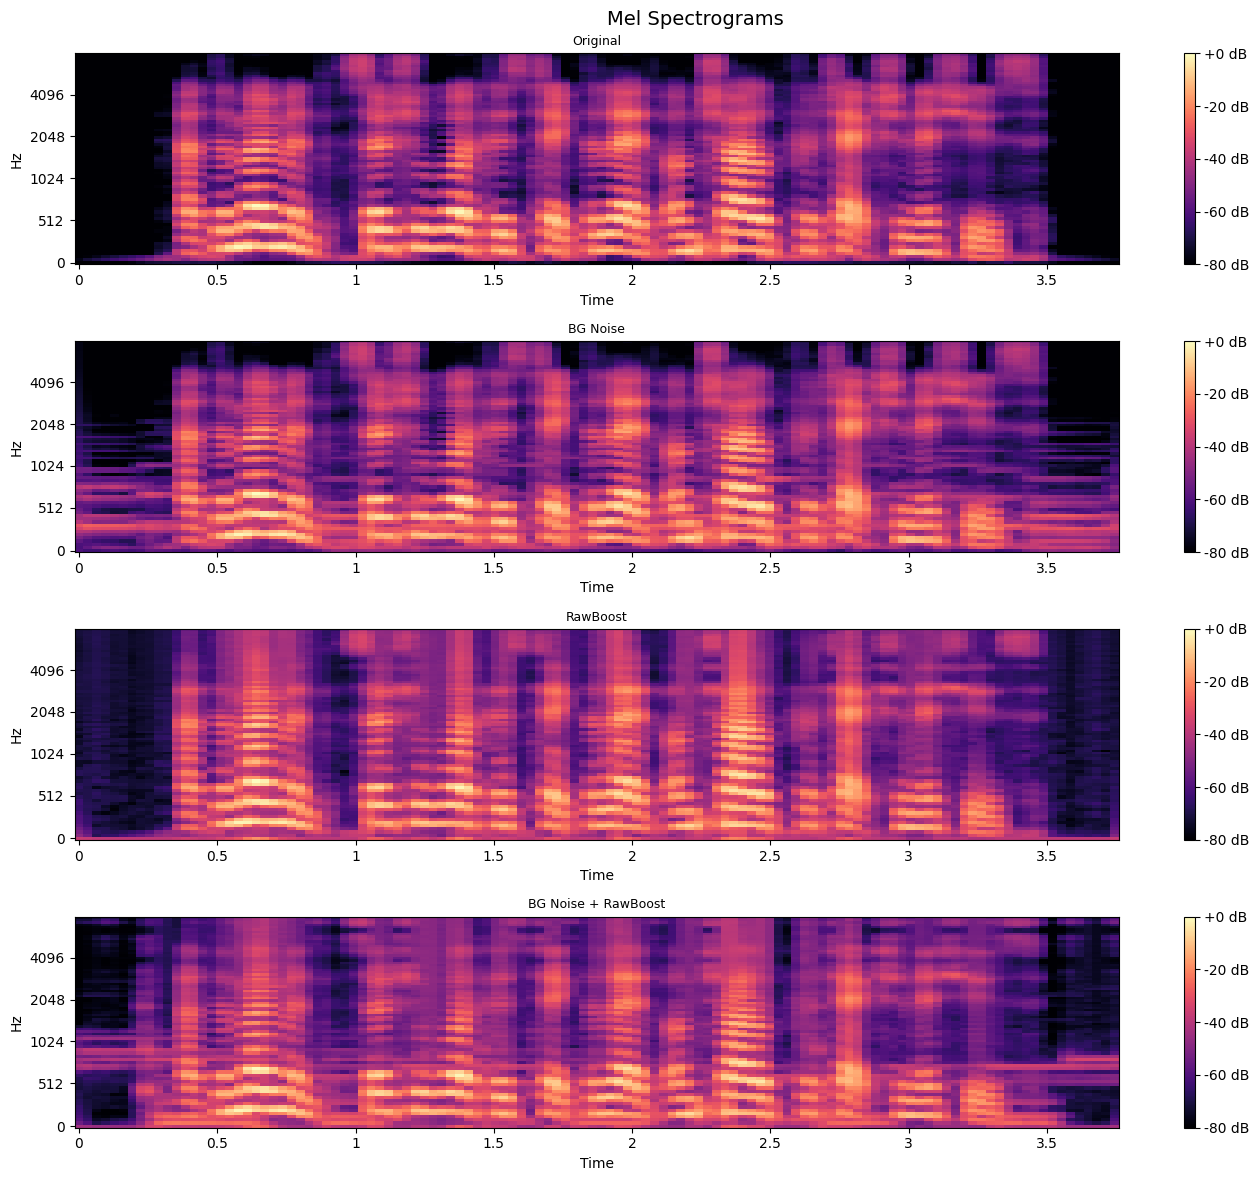

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("Mel Spectrograms", fontsize=14)
for ax, (title, wav) in zip(axes, variants):
    S = librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=SR, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(title, fontsize=9)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.show()

In [13]:
for title, wav in variants:
    print(f"--- {title} ---")
    display(Audio(wav, rate=SR))

--- Original ---


--- BG Noise ---


--- RawBoost ---


--- BG Noise + RawBoost ---


In [14]:
print("Stats summary")
print(f"{'Variant':<25} {'RMS':>8} {'Peak':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for title, wav in variants:
    rms  = np.sqrt(np.mean(wav ** 2))
    peak = np.max(np.abs(wav))
    print(f"{title:<25} {rms:>8.4f} {peak:>8.4f} {wav.min():>8.4f} {wav.max():>8.4f}")

Stats summary
Variant                        RMS     Peak      Min      Max
------------------------------------------------------------
Original                    0.1250   1.0000  -0.8714   1.0000
BG Noise                    0.1251   1.0000  -0.8690   1.0000
RawBoost                    0.0342   1.0000  -0.1727   1.0000
BG Noise + RawBoost         0.0603   1.0000  -0.4461   1.0000
